# MM26 Machine Learning Model Walkthrough

## The Cinderella System

This notebook walks through, step by step, how the machine learning pipeline powering our March Madness predictions works. The thesis is the **Cinderella System**: a model that identifies teams outperforming expectations using a heat variable, then converts those signals into calibrated matchup probabilities.

### How It Works

1. **ELO Engine** - Establish baseline expectations using margin-of-victory ELO with season carry-over and home court adjustment
2. **Heat Variable** - Compare actual performance to ELO expectations over 1, 3, and 5-game windows
3. **Feature Engineering** - Build pairwise difference features from team-level season stats, quality, and market context
4. **XGBoost Model** - Train a gradient-boosted classifier on historical tournament outcomes (2003-2024)
5. **Isotonic Calibration** - Calibrate raw probabilities with out-of-fold time-series CV predictions
6. **Dynamic Clipping** - Apply seed-matchup-aware probability bounds
7. **Submission Output** - Export model-only predictions to Kaggle-ready `submission.csv`

### Where the Submission Lives

The final Kaggle submission file is at **`artifacts/latest/submission.csv`**.

Format: `ID,Pred` where `ID = Season_TeamLow_TeamHigh` and `Pred = P(TeamLow wins)`.

---

In [37]:
from __future__ import annotations
import json, sys
from pathlib import Path
import numpy as np
import polars as pl

# Add project root to path so we can import pipeline helpers
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

BASE = ROOT / "artifacts" / "latest"

# Load run manifest and model diagnostics
manifest = json.loads((BASE / "run_manifest.json").read_text(encoding="utf-8"))
perf = json.loads((BASE / "reports" / "model_performance_summary.json").read_text(encoding="utf-8"))

# Load gold-layer artifacts
elo_ratings = pl.read_parquet(BASE / "gold" / "elo_ratings.parquet")
heat_scores = pl.read_parquet(BASE / "gold" / "heat_scores.parquet")
team_features = pl.read_parquet(BASE / "gold" / "team_season_features.parquet")
pairwise_features = pl.read_parquet(BASE / "gold" / "pairwise_features.parquet")
submission = pl.read_csv(BASE / "submission.csv")

# Load team names for display
teams = pl.read_csv(ROOT / "data" / "MTeams.csv").select("TeamID", "TeamName")
seeds_all = pl.read_csv(ROOT / "data" / "MNCAATourneySeeds.csv")
seeds_2026 = seeds_all.filter(pl.col("Season") == 2026)
slots_2026 = pl.read_csv(ROOT / "data" / "MNCAATourneySlots.csv").filter(pl.col("Season") == 2026)

# Optional: matplotlib for charts
try:
    import matplotlib.pyplot as plt
    HAS_PLT = True
except ImportError:
    HAS_PLT = False
    print("matplotlib not installed — charts will be skipped")

print(f"Run ID        : {manifest['run_id']}")
print(f"Target season : {manifest['target_season']}")
print(f"Model type    : {perf['model_stats']['M']['model_type']}")
print(f"Holdout Brier : {perf['model_stats']['M']['holdout_brier']:.4f}")
print(f"\nGold artifacts loaded:")
print(f"  elo_ratings      : {elo_ratings.shape}")
print(f"  heat_scores      : {heat_scores.shape}")
print(f"  team_features    : {team_features.shape}")
print(f"  pairwise_features: {pairwise_features.shape}")
print(f"  submission       : {submission.shape}")

Run ID        : 20260319T124948Z_518529c7
Target season : 2026
Model type    : ensemble_xgb_lr
Holdout Brier : 0.1322

Gold artifacts loaded:
  elo_ratings      : (423432, 11)
  heat_scores      : (423432, 13)
  team_features    : (14311, 50)
  pairwise_features: (132133, 137)
  submission       : (132133, 2)


---

## Step 1 — The ELO Engine

ELO is a rating system originally designed for chess. Every team starts at **1500** in their first season, with 33% carry-over of prior season deviation in subsequent seasons. After each game, ratings shift based on the result vs. expectations:

- **K-factor = 20** (base), scaled by **margin-of-victory**: $K_{\text{eff}} = K \times \frac{\log(|\text{margin}|+1) \times 2.2}{\Delta_{\text{ELO}} \times 0.001 + 2.2}$
- **Home court advantage**: +100 ELO for the home team
- **Expected win probability**: $P(\text{low wins}) = \frac{1}{1 + 10^{-(\text{ELO}_\text{low} - \text{ELO}_\text{high}) / 400}}$
- **Expected margin**: $25 \times (2 \times P(\text{low wins}) - 1)$
- **Season carry-over**: $\text{ELO}_{\text{new season}} = 1500 + 0.33 \times (\text{ELO}_{\text{end prev}} - 1500)$

A team that beats a much higher-rated opponent *by a large margin* will gain more ELO than one that barely wins. By season's end, the top ELO teams are the ones that have *consistently performed well against quality opponents*.

Let's look at how ELO evolved for a few 2026 tournament teams:

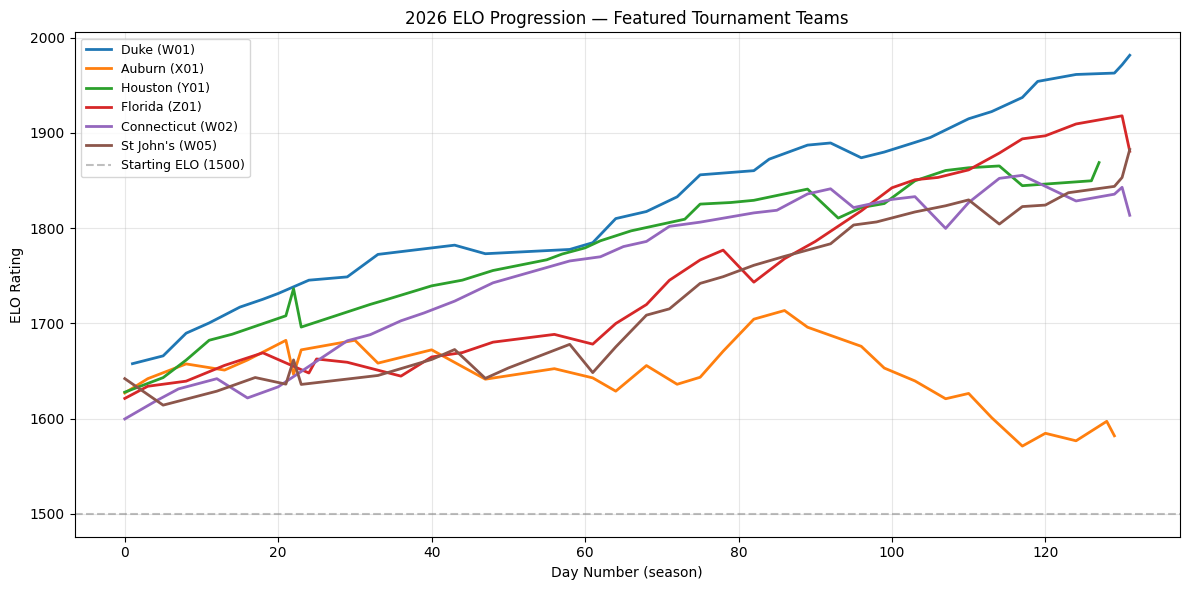

In [38]:
# ELO progression for featured 2026 tournament teams
FEATURED_TEAMS = {
    1181: "Duke (W01)",
    1120: "Auburn (X01)",
    1211: "Houston (Y01)",
    1196: "Florida (Z01)",
    1163: "Connecticut (W02)",
    1385: "St John's (W05)",
}

elo_2026 = elo_ratings.filter(
    (pl.col("sex") == "M") & (pl.col("season") == 2026)
)

if HAS_PLT:
    fig, ax = plt.subplots(figsize=(12, 6))
    for tid, label in FEATURED_TEAMS.items():
        team_elo = elo_2026.filter(pl.col("team_id") == tid).sort("day_num")
        if team_elo.height > 0:
            ax.plot(
                team_elo["day_num"].to_numpy(),
                team_elo["elo_after"].to_numpy(),
                label=label, linewidth=2,
            )
    ax.axhline(y=1500, color="gray", linestyle="--", alpha=0.5, label="Starting ELO (1500)")
    ax.set_xlabel("Day Number (season)")
    ax.set_ylabel("ELO Rating")
    ax.set_title("2026 ELO Progression — Featured Tournament Teams")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    # Text fallback
    for tid, label in FEATURED_TEAMS.items():
        team_elo = elo_2026.filter(pl.col("team_id") == tid).sort("day_num")
        if team_elo.height > 0:
            final_elo = team_elo["elo_after"][-1]
            print(f"  {label:25s} → Final ELO: {final_elo:.1f}")

In [39]:
# Top 20 teams by season-end ELO for 2026 Men's tournament
m_2026_features = team_features.filter(
    (pl.col("sex") == "M") & (pl.col("season") == 2026)
)

# Join with seeds and team names
tourney_teams = (
    m_2026_features
    .join(seeds_2026.select(
        pl.col("TeamID").cast(pl.Int64).alias("team_id"),
        pl.col("Seed"),
    ), on="team_id", how="inner")
    .join(teams.rename({"TeamID": "team_id"}), on="team_id", how="left")
    .with_columns(
        pl.col("Seed").str.extract(r"(\d+)", 1).cast(pl.Int64).alias("seed_num"),
    )
    .sort("season_end_elo", descending=True)
)

print("Top 20 Teams by ELO — 2026 Men's Tournament\n")
print(f"{'Seed':<6} {'Team':<22} {'ELO':>8} {'Win Rate':>10} {'Record':>10}")
print("─" * 60)
for row in tourney_teams.head(20).iter_rows(named=True):
    record = f"{row['wins']}-{row['losses']}"
    print(f"{row['Seed']:<6} {row['TeamName']:<22} {row['season_end_elo']:>8.1f} {row['win_rate']:>9.1%} {record:>10}")

Top 20 Teams by ELO — 2026 Men's Tournament

Seed   Team                        ELO   Win Rate     Record
────────────────────────────────────────────────────────────
W01    Duke                     1981.6     94.1%       32-2
Z01    Arizona                  1948.5     94.1%       32-2
Y01    Michigan                 1943.6     91.2%       31-3
W05    St John's                1882.6     82.4%       28-6
X01    Florida                  1880.8     78.8%       26-7
Z03    Gonzaga                  1868.9     90.9%       30-3
X02    Houston                  1844.4     82.4%       28-6
Y03    Virginia                 1837.5     85.3%       29-5
Z02    Purdue                   1836.1     77.1%       27-8
X07    St Mary's CA             1816.3     83.9%       26-5
Z04    Arkansas                 1814.8     76.5%       26-8
W02    Connecticut              1813.5     85.3%       29-5
X11    VCU                      1808.3     79.4%       27-7
Y12    Akron                    1803.5     84.4%     

---

## Step 2 — The Heat Variable (Cinderella Detection)

The **heat variable** is the core innovation. It measures how much a team is *outperforming their ELO-based expectations*:

$$\text{heat\_delta} = \text{actual\_margin} - \text{expected\_margin}$$

We compute rolling averages over three lookback windows:
- **heat_1g** — Last 1 game (most recent momentum)
- **heat_3g** — Average of last 3 games (short-term trend)
- **heat_5g** — Average of last 5 games (sustained over-performance)

A team with **positive heat** heading into the tournament is winning by *more* than their ELO predicts — they're "hot." A team with **negative heat** is underperforming expectations — they're "cold."

The hypothesis: **hot teams are more likely to pull upsets**, and this signal improves our predictions beyond what traditional stats capture.

In [40]:
# Show the hottest and coldest teams entering the 2026 Men's tournament
heat_display = (
    tourney_teams
    .select("Seed", "TeamName", "season_end_elo", "pre_tourney_heat_1g", "pre_tourney_heat_3g", "pre_tourney_heat_5g")
)

print("🔥 HOTTEST Teams (by 5-game heat) entering 2026 Tournament\n")
print(f"{'Seed':<6} {'Team':<22} {'ELO':>7} {'Heat 1g':>9} {'Heat 3g':>9} {'Heat 5g':>9}")
print("─" * 65)
hot = heat_display.sort("pre_tourney_heat_5g", descending=True).head(10)
for row in hot.iter_rows(named=True):
    h1 = row["pre_tourney_heat_1g"] or 0
    h3 = row["pre_tourney_heat_3g"] or 0
    h5 = row["pre_tourney_heat_5g"] or 0
    print(f"{row['Seed']:<6} {row['TeamName']:<22} {row['season_end_elo']:>7.1f} {h1:>+9.2f} {h3:>+9.2f} {h5:>+9.2f}")

print("\n\n❄️  COLDEST Teams (by 5-game heat) entering 2026 Tournament\n")
print(f"{'Seed':<6} {'Team':<22} {'ELO':>7} {'Heat 1g':>9} {'Heat 3g':>9} {'Heat 5g':>9}")
print("─" * 65)
cold = heat_display.sort("pre_tourney_heat_5g", descending=False).head(10)
for row in cold.iter_rows(named=True):
    h1 = row["pre_tourney_heat_1g"] or 0
    h3 = row["pre_tourney_heat_3g"] or 0
    h5 = row["pre_tourney_heat_5g"] or 0
    print(f"{row['Seed']:<6} {row['TeamName']:<22} {row['season_end_elo']:>7.1f} {h1:>+9.2f} {h3:>+9.2f} {h5:>+9.2f}")

🔥 HOTTEST Teams (by 5-game heat) entering 2026 Tournament

Seed   Team                       ELO   Heat 1g   Heat 3g   Heat 5g
─────────────────────────────────────────────────────────────────
X16b   Prairie View            1471.9    +20.74    +12.02    +14.39
Y15    Tennessee St            1667.1     +6.02    +17.34    +14.14
Y16b   UMBC                    1647.3     +5.05    +10.17     +8.74
Z05    Wisconsin               1750.9     +8.30     +4.72     +8.72
Y16a   Howard                  1600.2     +1.75     +2.27     +8.48
Y02    Iowa St                 1800.7    +19.57    +20.29     +8.43
W07    UCLA                    1716.3    +10.23     +8.92     +8.13
X15    Idaho                   1556.3    +13.19    +11.77     +7.94
X01    Florida                 1880.8     -6.26     +1.28     +6.03
W09    TCU                     1690.2     -1.48     +8.48     +5.89


❄️  COLDEST Teams (by 5-game heat) entering 2026 Tournament

Seed   Team                       ELO   Heat 1g   Heat 3g   Heat

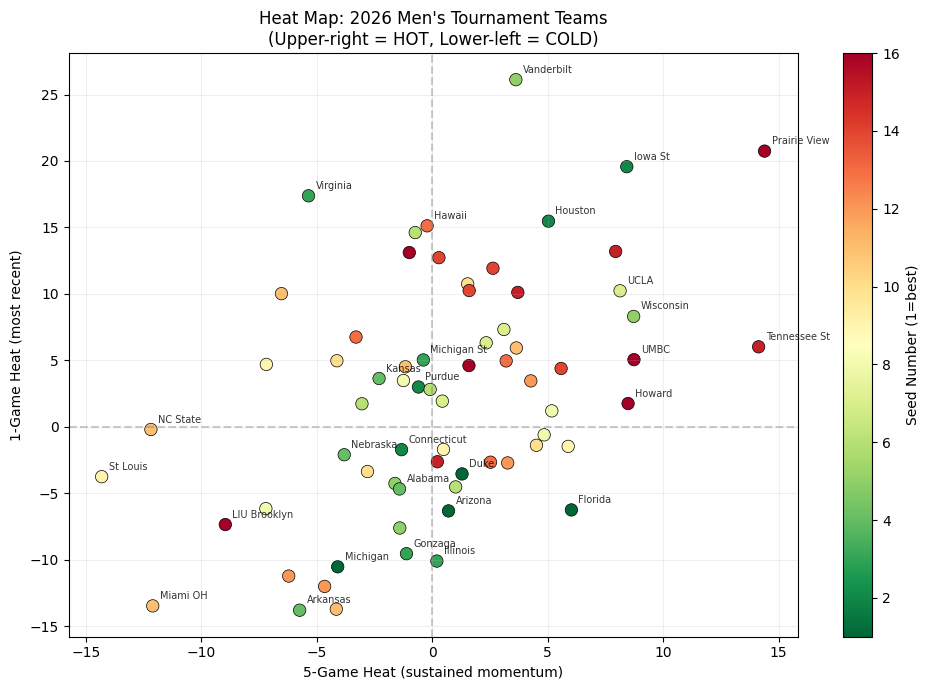

In [41]:
# Heat distribution scatter: 1-game vs 5-game heat for all 2026 M tourney teams
if HAS_PLT:
    fig, ax = plt.subplots(figsize=(10, 7))
    h1 = tourney_teams["pre_tourney_heat_1g"].fill_null(0).to_numpy()
    h5 = tourney_teams["pre_tourney_heat_5g"].fill_null(0).to_numpy()
    seed_nums = tourney_teams["seed_num"].to_numpy()
    names = tourney_teams["TeamName"].to_list()

    scatter = ax.scatter(h5, h1, c=seed_nums, cmap="RdYlGn_r", s=80, edgecolors="black", linewidth=0.5)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Seed Number (1=best)")

    # Label notable teams
    for i, name in enumerate(names):
        if seed_nums[i] <= 4 or abs(h5[i]) > 8 or abs(h1[i]) > 15:
            ax.annotate(name, (h5[i], h1[i]), fontsize=7, alpha=0.8,
                        xytext=(5, 5), textcoords="offset points")

    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.4)
    ax.axvline(x=0, color="gray", linestyle="--", alpha=0.4)
    ax.set_xlabel("5-Game Heat (sustained momentum)")
    ax.set_ylabel("1-Game Heat (most recent)")
    ax.set_title("Heat Map: 2026 Men's Tournament Teams\n(Upper-right = HOT, Lower-left = COLD)")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("Install matplotlib to see the heat scatter plot")

---

## Step 3 — Feature Engineering

For every possible matchup (e.g., `2026_1181_1120` = Duke vs Auburn), we compute **28 candidate pairwise difference features**. These capture the relative strength between the two teams across offensive, defensive, momentum, and market dimensions:

| Feature | What It Captures |
|---|---|
| `diff_win_rate` | Overall record strength |
| `diff_avg_margin` | Typical scoring dominance |
| `diff_avg_pts_for` | Offensive firepower |
| `diff_defense_proxy` | Defensive strength (flipped) |
| `diff_last5_win_rate` | Recent form |
| `diff_last5_avg_margin` | Recent scoring trend |
| `diff_elo` | ELO-based strength gap |
| `diff_heat_1g` | **Latest momentum gap** |
| `diff_heat_3g` | **Short-term heat gap** |
| `diff_heat_5g` | **Sustained heat gap** |
| `diff_heat_trend` | **Heat trajectory (5g - 1g)** |
| `diff_abs_heat_5g` | **Absolute heat volatility** |
| `diff_seed` | Seeding gap (lower = better) |
| `diff_sos` | Strength of schedule (opponent ELO avg) |
| `diff_fg_pct` | Field goal shooting efficiency |
| `diff_fg3_pct` | Three-point shooting efficiency |
| `diff_ft_pct` | Free throw shooting efficiency |
| `diff_opp_fg_pct` | Opponent FG% (defensive quality) |
| `diff_reb_margin` | Rebounding margin |
| `diff_ast_to_ratio` | Assist-to-turnover ratio |
| `diff_stl_blk` | Steals + blocks (disruptiveness) |
| `diff_possessions` | Tempo proxy (pace of play) |
| `seed_product` | Seed interaction (seed_low × seed_high) |
| `consensus_low_spread_filled` | Betting line spread (market consensus) |

> **Convention**: All diff features are computed as *low_team_stat − high_team_stat*. Positive values favor the lower-ID team.

Let's look at a concrete example:

In [42]:
# Concrete example: pick two 2026 tournament teams and show their raw stats + difference
TEAM_A_ID = 1120  # Auburn (X01 — a 1-seed)
TEAM_B_ID = 1254  # LIU Brooklyn (Z16 — a 16-seed)

team_a = m_2026_features.filter(pl.col("team_id") == TEAM_A_ID).to_dicts()[0]
team_b = m_2026_features.filter(pl.col("team_id") == TEAM_B_ID).to_dicts()[0]

name_a = teams.filter(pl.col("TeamID") == TEAM_A_ID)["TeamName"][0]
name_b = teams.filter(pl.col("TeamID") == TEAM_B_ID)["TeamName"][0]

stat_cols = [
    ("win_rate", "Win Rate"),
    ("avg_margin", "Avg Margin"),
    ("avg_pts_for", "Avg Pts For"),
    ("avg_pts_against", "Avg Pts Against"),
    ("last5_win_rate", "Last 5 Win Rate"),
    ("last5_avg_margin", "Last 5 Avg Margin"),
    ("season_end_elo", "Season End ELO"),
    ("pre_tourney_heat_1g", "Heat 1g"),
    ("pre_tourney_heat_3g", "Heat 3g"),
    ("pre_tourney_heat_5g", "Heat 5g"),
    ("sos", "Strength of Schedule"),
    ("fg_pct", "FG%"),
    ("fg3_pct", "3PT%"),
    ("ft_pct", "FT%"),
    ("avg_reb_margin", "Reb Margin"),
    ("ast_to_ratio", "Ast/TO Ratio"),
    ("avg_stl_blk", "Steals + Blocks"),
    ("avg_possessions", "Possessions (Tempo)"),
]

# Note: in the matchup ID, the lower TeamID always comes first
low_id, high_id = min(TEAM_A_ID, TEAM_B_ID), max(TEAM_A_ID, TEAM_B_ID)
low_name = name_a if TEAM_A_ID == low_id else name_b
high_name = name_b if TEAM_A_ID == low_id else name_a
low_stats = team_a if TEAM_A_ID == low_id else team_b
high_stats = team_b if TEAM_A_ID == low_id else team_a

print(f"Matchup: {low_name} (ID {low_id}) vs {high_name} (ID {high_id})")
print(f"Submission ID: 2026_{low_id}_{high_id}\n")
print(f"{'Stat':<22} {low_name:>14} {high_name:>14} {'Difference':>12}")
print("─" * 65)
for col, label in stat_cols:
    val_low = low_stats.get(col) or 0
    val_high = high_stats.get(col) or 0
    diff = val_low - val_high
    if col == "avg_pts_against":
        diff = val_high - val_low  # Defense proxy is flipped
    print(f"{label:<22} {val_low:>14.3f} {val_high:>14.3f} {diff:>+12.3f}")

Matchup: Auburn (ID 1120) vs LIU Brooklyn (ID 1254)
Submission ID: 2026_1120_1254

Stat                           Auburn   LIU Brooklyn   Difference
─────────────────────────────────────────────────────────────────
Win Rate                        0.515          0.706       -0.191
Avg Margin                      3.333          2.971       +0.363
Avg Pts For                    82.727         74.088       +8.639
Avg Pts Against                79.394         71.118       -8.276
Last 5 Win Rate                 0.400          1.000       -0.600
Last 5 Avg Margin               0.800         10.400       -9.600
Season End ELO               1581.897       1603.147      -21.249
Heat 1g                        11.140         -7.358      +18.498
Heat 3g                         5.902         -9.745      +15.647
Heat 5g                        -3.547         -8.964       +5.416
Strength of Schedule         1649.244       1405.407     +243.836
FG%                             0.457          0.481       

In [43]:
# Show the actual feature vector from the pairwise_features table for this matchup
FEATURE_COLS = perf["feature_cols"]  # Load from model report to stay in sync with pipeline

matchup_id = f"2026_{low_id}_{high_id}"
matchup_row = pairwise_features.filter(pl.col("ID") == matchup_id)

if matchup_row.height > 0:
    print(f"Feature vector for {matchup_id} ({low_name} vs {high_name}):\n")
    print(f"{'Feature':<32} {'Value':>10}")
    print("─" * 44)
    row = matchup_row.to_dicts()[0]
    for col in FEATURE_COLS:
        val = row.get(col)
        val_str = f"{val:>+10.3f}" if val is not None else "      null"
        print(f"{col:<32} {val_str}")

    print(f"\n→ Current submission prediction: {submission.filter(pl.col('ID') == matchup_id)['Pred'][0]:.4f}")
    print(f"  (P({low_name} beats {high_name}))")
else:
    print(f"Matchup {matchup_id} not found in pairwise features")

Feature vector for 2026_1120_1254 (Auburn vs LIU Brooklyn):

Feature                               Value
────────────────────────────────────────────
diff_win_rate                        -0.191
diff_avg_margin                      +0.363
diff_avg_pts_for                     +8.639
diff_defense_proxy                   -8.276
diff_last5_win_rate                  -0.600
diff_last5_avg_margin                -9.600
diff_elo                            -21.249
diff_heat_1g                        +18.498
diff_heat_3g                        +15.647
diff_heat_5g                         +5.416
diff_heat_trend                     -13.082
diff_abs_heat_5g                     -5.416
diff_seed                            -8.000
diff_sos                           +243.836
diff_fg_pct                          -0.024
diff_fg3_pct                         -0.024
diff_ft_pct                          +0.076
diff_opp_fg_pct                      +0.018
diff_reb_margin                      +0.358
diff_ast_to_ra

---

## Step 4 — XGBoost Training, Calibration, and Importance

We train an XGBoost classifier on historical tournament outcomes and calibrate probabilities with isotonic regression fitted on out-of-fold predictions from time-series CV.

**Validation setup:**
- Train window: 2003-2024
- Holdout season: 2025
- Prediction target: 2026

The cell below retrains the model using pipeline helpers, reports CV and holdout Brier, and prints feature importances from the trained model.

Training rows (M, <=2024): 2518
Holdout rows  (M, 2025): 67
Feature count: 33
Time-series CV Brier mean: 0.19229
  Fold 2019: 0.15902
  Fold 2020: 0.22647
  Fold 2021: 0.22411
  Fold 2022: 0.21544
  Fold 2023: 0.19026
  Fold 2024: 0.13847
Holdout Brier (2025): 0.13859

Top feature importances:
  diff_seed                              0.1513
  diff_quality                           0.0974
  diff_quality_minus_elo                 0.0800
  diff_elo                               0.0396
  diff_massey_rank                       0.0362
  diff_net_rating                        0.0349
  diff_off_rating                        0.0264
  diff_fg_pct                            0.0255
  diff_avg_pts_for                       0.0249
  diff_massey_best                       0.0249
  diff_sos                               0.0245
  diff_sw_heat_5g                        0.0241
  diff_abs_heat_5g                       0.0232
  seed_product                           0.0227
  diff_win_rate                  

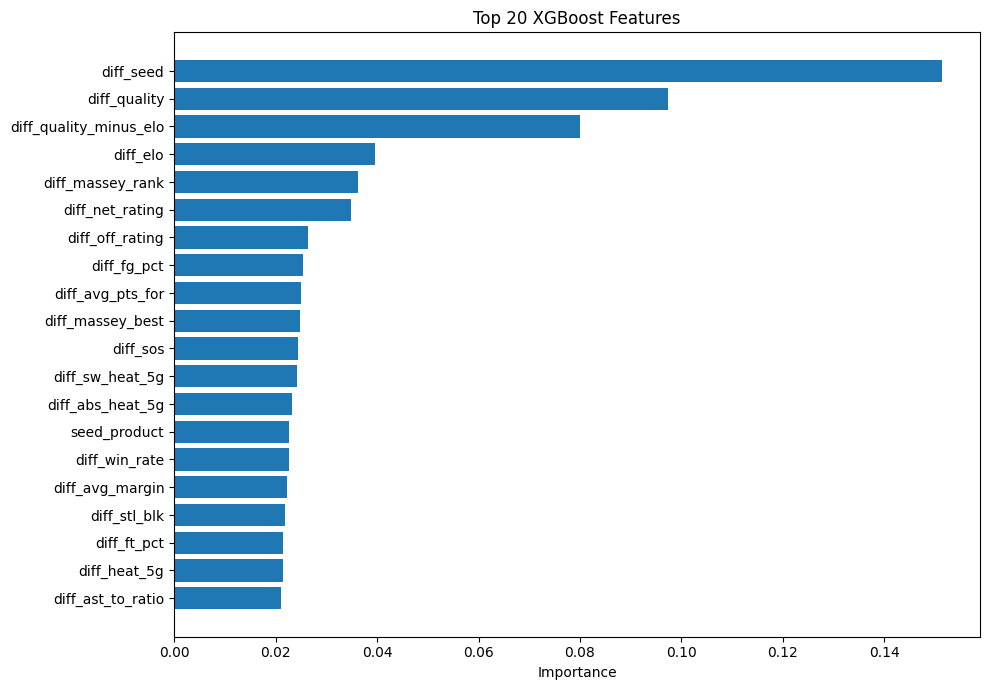

In [44]:
# Retrain model and inspect feature importance using pipeline helpers
import importlib
import copy

import mm26.pipeline as _pipeline_mod
importlib.reload(_pipeline_mod)

from mm26.pipeline import (
    _build_training_pairs,
    _fit_calibration,
    _load_seed_map,
    _predict_with_model,
    _time_series_cv_brier,
    _train_model,
)

ingest_manifest = copy.deepcopy(manifest["ingest"])
for source_key in ("kaggle", "cbbd"):
    if source_key not in ingest_manifest:
        continue
    files = ingest_manifest[source_key].get("files", {})
    for file_info in files.values():
        if "artifact" in file_info:
            file_info["artifact"] = str(ROOT / file_info["artifact"])

seed_map = _load_seed_map(ingest_manifest)
training = _build_training_pairs(ingest_manifest, team_features, target_season=2026, seed_map=seed_map)

FEATURE_COLS = perf["feature_cols"]
train_m = training.filter((pl.col("sex") == "M") & (pl.col("season") <= 2024))
holdout_m = training.filter((pl.col("sex") == "M") & (pl.col("season") == 2025))

print(f"Training rows (M, <=2024): {train_m.height}")
print(f"Holdout rows  (M, 2025): {holdout_m.height}")
print(f"Feature count: {len(FEATURE_COLS)}")

model = _train_model(train_m, FEATURE_COLS, n_estimators=500)
calibrator = _fit_calibration(model, training, FEATURE_COLS, sex="M")
cv_brier, cv_folds = _time_series_cv_brier(training, FEATURE_COLS, sex="M")

print(f"Time-series CV Brier mean: {cv_brier:.5f}")
for i, b in enumerate(cv_folds):
    print(f"  Fold {2019 + i}: {b:.5f}")

if holdout_m.height > 0:
    holdout_preds = _predict_with_model(model, holdout_m, FEATURE_COLS, calibrator=calibrator)
    actuals = holdout_m.select("target_low_wins").to_series().to_numpy().astype(np.float64)
    holdout_brier = float(np.mean((holdout_preds.to_numpy() - actuals) ** 2))
    print(f"Holdout Brier (2025): {holdout_brier:.5f}")

if hasattr(model, "feature_importances_"):
    importances = dict(zip(FEATURE_COLS, model.feature_importances_))
    sorted_imp = sorted(importances.items(), key=lambda x: x[1], reverse=True)
    print("\nTop feature importances:")
    for feat, imp in sorted_imp[:15]:
        print(f"  {feat:<36} {imp:>8.4f}")

    if HAS_PLT:
        fig, ax = plt.subplots(figsize=(10, 7))
        names = [x[0] for x in sorted_imp[:20]][::-1]
        vals = [x[1] for x in sorted_imp[:20]][::-1]
        ax.barh(names, vals)
        ax.set_title("Top 20 XGBoost Features")
        ax.set_xlabel("Importance")
        plt.tight_layout()
        plt.show()

---

## Step 5 — Submission Contract Checks and Export

This final step validates the output contract before writing `artifacts/latest/submission.csv`.

Checks performed:
- non-zero row count
- ID format is `Season_TeamLow_TeamHigh`
- no null probabilities
- prediction values remain inside [0, 1]

In [45]:
# Validate and export submission
out = submission.with_columns(pl.col("Pred").cast(pl.Float64))

bad_id = out.filter(~pl.col("ID").str.contains(r"^\d{4}_\d+_\d+$")).height
null_pred = out.filter(pl.col("Pred").is_null()).height
out_of_bounds = out.filter((pl.col("Pred") < 0.0) | (pl.col("Pred") > 1.0)).height

print(f"Rows          : {out.height:,}")
print(f"Malformed IDs : {bad_id}")
print(f"Null Pred     : {null_pred}")
print(f"Out of bounds : {out_of_bounds}")
print(f"Pred range    : [{out['Pred'].min():.4f}, {out['Pred'].max():.4f}]")

output_path = BASE / "submission.csv"
out.write_csv(output_path)
print(f"Wrote: {output_path}")

Rows          : 132,133
Malformed IDs : 0
Null Pred     : 0
Out of bounds : 0
Pred range    : [0.0100, 0.9900]
Wrote: C:\Users\sdiehl\Desktop\seandiehlprojects\mm26\artifacts\latest\submission.csv
